# Bootstrap — Visualizações
Lê os resultados pré-computados do `bootstrap_ic.ipynb` sem necessidade de re-executar o bootstrap.
- `bootstrap_ic95.csv` → tabelas e forest plot
- `bootstrap_distribuicoes.parquet` → histogramas de distribuição

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

OUTPUT_MET = '../../output/metricas'
OUTPUT_PLT = '../../output/plots'
os.makedirs(OUTPUT_PLT, exist_ok=True)

df_ic   = pd.read_csv(os.path.join(OUTPUT_MET, 'bootstrap_ic95.csv'))
df_dist = pd.read_parquet(os.path.join(OUTPUT_MET, 'bootstrap_distribuicoes.parquet'))

N_BOOTSTRAP = df_dist.groupby('modelo').size().iloc[0]
modelos_ord_auprc = (
    df_ic[df_ic['metrica'] == 'auprc']
    .sort_values('estimativa', ascending=False)['modelo']
    .tolist()
)

print(f'ICs carregados:           {len(df_ic)} linhas ({df_ic["modelo"].nunique()} modelos × 3 métricas)')
print(f'Distribuições carregadas: {len(df_dist):,} linhas ({N_BOOTSTRAP} iterações × {df_dist["modelo"].nunique()} modelos)')

ICs carregados:           33 linhas (11 modelos × 3 métricas)
Distribuições carregadas: 11,000 linhas (1000 iterações × 11 modelos)


## 1. Tabelas de IC 95%

In [2]:
for metrica in ['sensibilidade', 'auprc', 'roc_auc']:
    sub = (
        df_ic[df_ic['metrica'] == metrica]
        .sort_values('estimativa', ascending=False)
        [['modelo', 'estimativa', 'ic_low', 'ic_high', 'ic_width']]
        .reset_index(drop=True)
    )
    sub['IC 95%'] = sub.apply(lambda r: f"[{r['ic_low']:.4f}, {r['ic_high']:.4f}]", axis=1)
    print(f'\n=== {metrica.upper()} ===')
    display(sub[['modelo', 'estimativa', 'IC 95%', 'ic_width']])


=== SENSIBILIDADE ===


,modelo,estimativa,IC 95%,ic_width
0,LR (tuned),0.8008,"[0.7904, 0.8108]",0.0204
1,LR,0.8004,"[0.7901, 0.8105]",0.0204
2,XGBoost (tuned),0.7932,"[0.7822, 0.8044]",0.0222
3,Ensemble (LR+MLP+LGBM),0.7843,"[0.7733, 0.7944]",0.0210
4,MLP,0.7843,"[0.7740, 0.7954]",0.0214
5,MLP (tuned),0.7664,"[0.7551, 0.7771]",0.0220
6,LightGBM (tuned),0.7549,"[0.7440, 0.7659]",0.0219
7,XGBoost,0.7490,"[0.7373, 0.7606]",0.0232
8,LightGBM,0.6820,"[0.6697, 0.6941]",0.0245
9,Random Forest,0.6240,"[0.6105, 0.6360]",0.0255



=== AUPRC ===


,modelo,estimativa,IC 95%,ic_width
0,Ensemble (LR+MLP+LGBM),0.6472,"[0.6329, 0.6586]",0.0257
1,MLP,0.6369,"[0.6219, 0.6497]",0.0278
2,XGBoost (tuned),0.6314,"[0.6167, 0.6431]",0.0264
3,LightGBM (tuned),0.6294,"[0.6154, 0.6416]",0.0262
4,Random Forest,0.6276,"[0.6132, 0.6399]",0.0267
5,MLP (tuned),0.6272,"[0.6119, 0.6404]",0.0286
6,Random Forest (tuned),0.6268,"[0.6120, 0.6386]",0.0265
7,LR,0.6250,"[0.6095, 0.6384]",0.0289
8,LR (tuned),0.6250,"[0.6096, 0.6383]",0.0287
9,XGBoost,0.6112,"[0.5961, 0.6233]",0.0271



=== ROC_AUC ===


,modelo,estimativa,IC 95%,ic_width
0,Ensemble (LR+MLP+LGBM),0.9261,"[0.9219, 0.9302]",0.0083
1,LR (tuned),0.9242,"[0.9201, 0.9283]",0.0082
2,LR,0.9242,"[0.9200, 0.9283]",0.0082
3,MLP,0.9217,"[0.9172, 0.9260]",0.0088
4,Random Forest,0.9209,"[0.9164, 0.9250]",0.0085
5,XGBoost (tuned),0.9194,"[0.9148, 0.9238]",0.0090
6,MLP (tuned),0.9157,"[0.9111, 0.9202]",0.0091
7,LightGBM (tuned),0.9136,"[0.9089, 0.9180]",0.0091
8,XGBoost,0.9098,"[0.9051, 0.9145]",0.0094
9,Random Forest (tuned),0.9038,"[0.8988, 0.9087]",0.0099


## 2. Forest plot — IC 95% por métrica

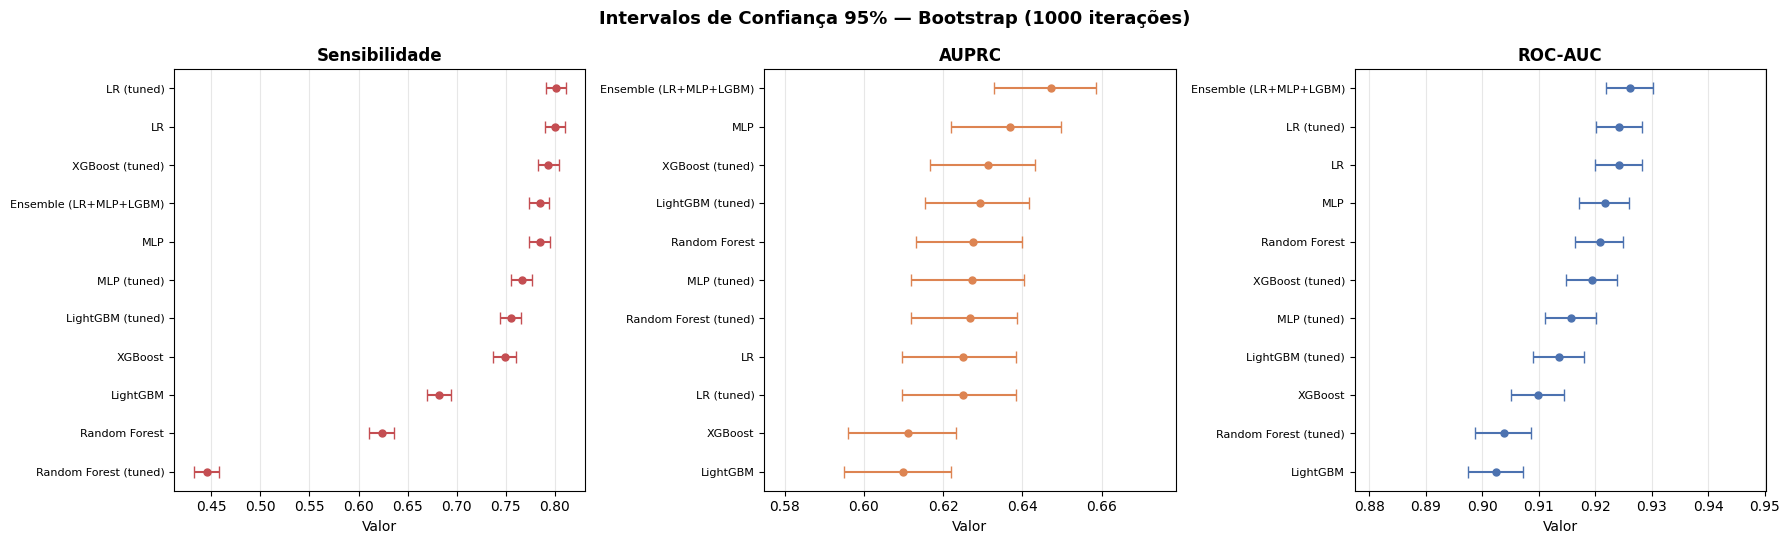

In [3]:
metricas_plot = [
    ('sensibilidade', '#C44E52', 'Sensibilidade'),
    ('auprc',         '#DD8452', 'AUPRC'),
    ('roc_auc',       '#4C72B0', 'ROC-AUC'),
]

n_modelos = df_ic['modelo'].nunique()
fig, axes = plt.subplots(1, 3, figsize=(18, max(5, n_modelos * 0.5)))

for ax, (metrica, cor, titulo) in zip(axes, metricas_plot):
    sub = (
        df_ic[df_ic['metrica'] == metrica]
        .sort_values('estimativa', ascending=True)
        .reset_index(drop=True)
    )
    y_pos   = np.arange(len(sub))
    xerr_lo = sub['estimativa'] - sub['ic_low']
    xerr_hi = sub['ic_high']   - sub['estimativa']

    ax.errorbar(
        sub['estimativa'], y_pos,
        xerr=[xerr_lo, xerr_hi],
        fmt='o', color=cor, ecolor=cor, elinewidth=1.5,
        capsize=4, markersize=5,
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub['modelo'], fontsize=8)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(
        max(0, sub['ic_low'].min() - 0.02),
        min(1, sub['ic_high'].max() + 0.02),
    )

plt.suptitle(f'Intervalos de Confiança 95% — Bootstrap ({N_BOOTSTRAP} iterações)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'bootstrap_forest_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Distribuição bootstrap — top 5 por AUPRC

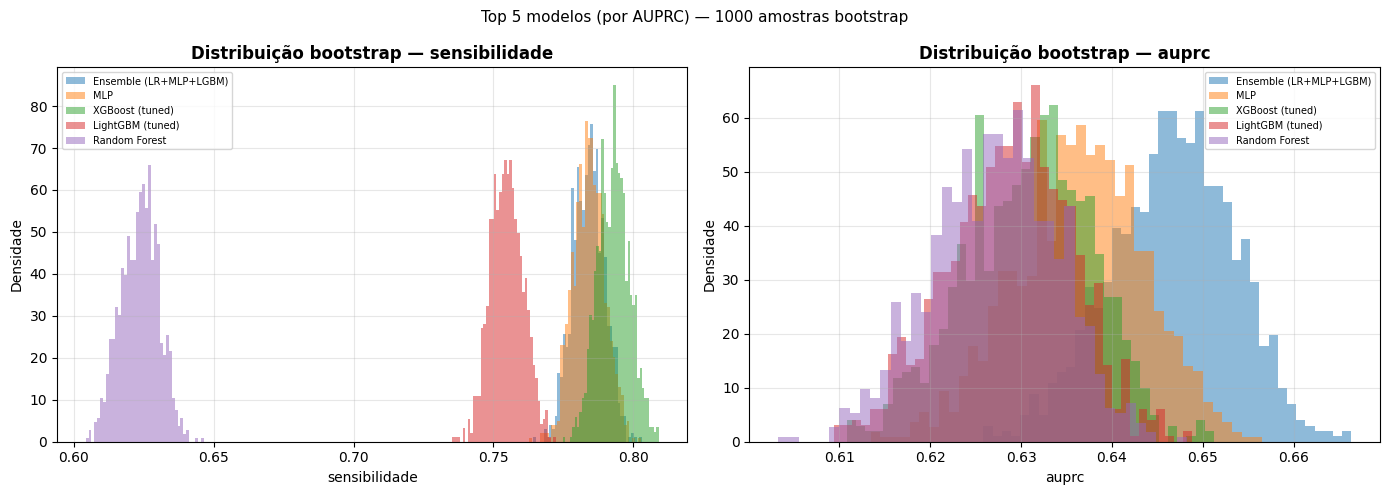

In [4]:
top5 = modelos_ord_auprc[:5]
df_top = df_dist[df_dist['modelo'].isin(top5)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metrica in zip(axes, ['sensibilidade', 'auprc']):
    for modelo in top5:
        vals = df_top[df_top['modelo'] == modelo][metrica]
        ax.hist(vals, bins=40, alpha=0.5, label=modelo, density=True)
    ax.set_title(f'Distribuição bootstrap — {metrica}', fontweight='bold')
    ax.set_xlabel(metrica)
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle(f'Top 5 modelos (por AUPRC) — {N_BOOTSTRAP} amostras bootstrap', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'bootstrap_distribuicoes.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Distribuição bootstrap — todos os modelos (boxplot)

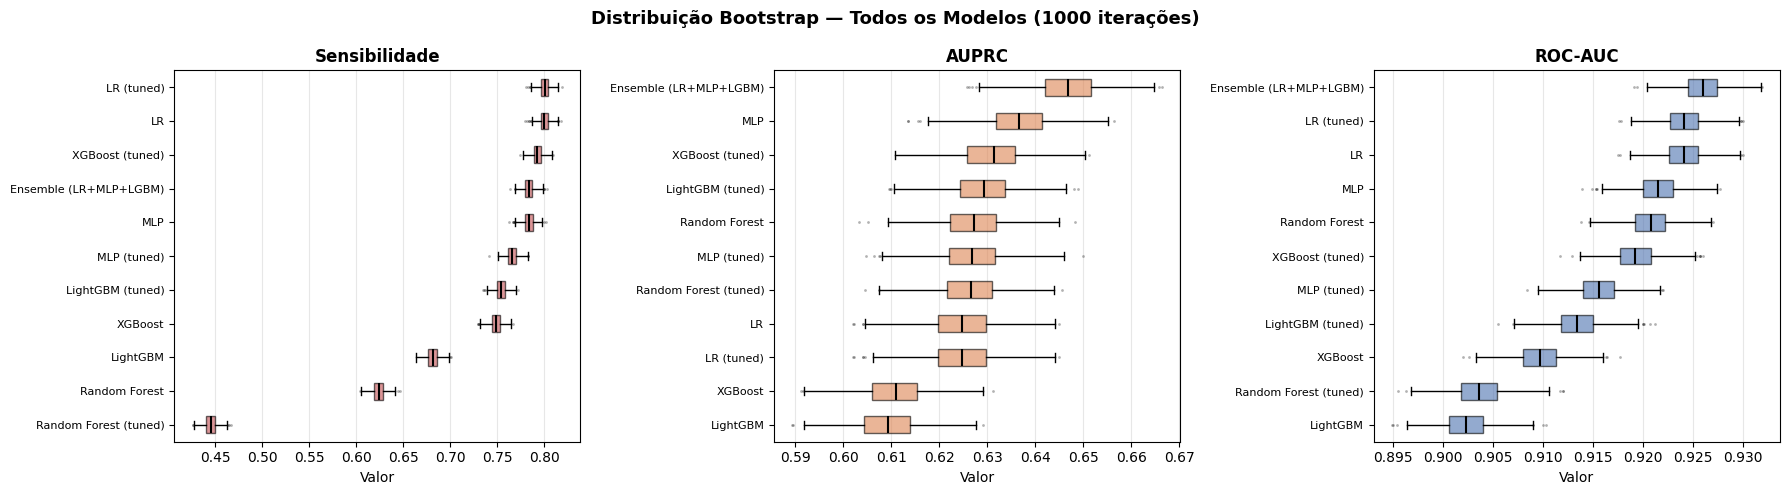

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, max(5, n_modelos * 0.45)))

cores = {'sensibilidade': '#C44E52', 'auprc': '#DD8452', 'roc_auc': '#4C72B0'}

for ax, (metrica, cor, titulo) in zip(axes, metricas_plot):
    ordem = (
        df_ic[df_ic['metrica'] == metrica]
        .sort_values('estimativa', ascending=True)['modelo']
        .tolist()
    )
    dados = [df_dist[df_dist['modelo'] == m][metrica].values for m in ordem]

    bp = ax.boxplot(
        dados, vert=False, patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 1.5},
        whiskerprops={'linewidth': 1},
        capprops={'linewidth': 1},
        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3},
    )
    for patch in bp['boxes']:
        patch.set_facecolor(cor)
        patch.set_alpha(0.6)

    ax.set_yticks(range(1, len(ordem) + 1))
    ax.set_yticklabels(ordem, fontsize=8)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle(f'Distribuição Bootstrap — Todos os Modelos ({N_BOOTSTRAP} iterações)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'bootstrap_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Comparação pareada — sobreposição de ICs
Dois modelos são considerados **estatisticamente distinguíveis** se seus ICs 95% não se sobrepõem (teste conservador).

In [6]:
for metrica in ['sensibilidade', 'auprc']:
    sub = df_ic[df_ic['metrica'] == metrica].set_index('modelo')
    modelos_ord = sub.sort_values('estimativa', ascending=False).index.tolist()

    print(f'\n=== Diferenças significativas — {metrica.upper()} ===')
    encontrou = False
    for m1, m2 in combinations(modelos_ord, 2):
        lo1, hi1 = sub.loc[m1, 'ic_low'], sub.loc[m1, 'ic_high']
        lo2, hi2 = sub.loc[m2, 'ic_low'], sub.loc[m2, 'ic_high']
        if hi1 < lo2 or hi2 < lo1:
            melhor = m1 if sub.loc[m1, 'estimativa'] > sub.loc[m2, 'estimativa'] else m2
            print(f'  {m1} vs {m2} → distinguíveis (melhor: {melhor})')
            encontrou = True
    if not encontrou:
        print('  Nenhum par com ICs não sobrepostos.')


=== Diferenças significativas — SENSIBILIDADE ===
  LR (tuned) vs MLP (tuned) → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs LightGBM (tuned) → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs XGBoost → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs LightGBM → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs Random Forest → distinguíveis (melhor: LR (tuned))
  LR (tuned) vs Random Forest (tuned) → distinguíveis (melhor: LR (tuned))
  LR vs MLP (tuned) → distinguíveis (melhor: LR)
  LR vs LightGBM (tuned) → distinguíveis (melhor: LR)
  LR vs XGBoost → distinguíveis (melhor: LR)
  LR vs LightGBM → distinguíveis (melhor: LR)
  LR vs Random Forest → distinguíveis (melhor: LR)
  LR vs Random Forest (tuned) → distinguíveis (melhor: LR)
  XGBoost (tuned) vs MLP (tuned) → distinguíveis (melhor: XGBoost (tuned))
  XGBoost (tuned) vs LightGBM (tuned) → distinguíveis (melhor: XGBoost (tuned))
  XGBoost (tuned) vs XGBoost → distinguíveis (melhor: XGBoost (tuned))
  XGBoost (tuned) v